# Proyecto Machine Learning: Predicción de Importe de Ventas
## Regresión Lineal con scikit-learn

### Contexto
Este notebook implementa un modelo de Machine Learning para **predecir el importe total de ventas** basándose en características como:
- Cantidad total de ítems vendidos
- Mes y día de la semana
- Método de pago

**Objetivo:** Regresión (predicción de valor numérico continuo)
**Algoritmo:** Regresión Lineal
**Dataset:** Datos de ventas y detalles de ventas de la tienda Aurelion

In [1]:
# 1. Librerías necesarias
import sys
sys.path.insert(0, '/Users/gusta/Documents/guayerd/aurelion/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configurar estilos de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Cargar y Explorar Dataset

In [2]:
# Cargar datos de ventas
ventas_df = pd.read_csv('/Users/gusta/Documents/guayerd/aurelion/bd/ventas.csv')
detalle_df = pd.read_csv('/Users/gusta/Documents/guayerd/aurelion/bd/detalle_ventas.csv')

# Combinar ventas con detalles de ventas
df_combined = pd.merge(ventas_df, detalle_df, on='id_venta', how='inner')

print("Dataset combinado - Shape:", df_combined.shape)
print("\nPrimeras filas:")
print(df_combined.head())
print("\nInformación del dataset:")
print(df_combined.info())
print("\nEstadísticas descriptivas:")
print(df_combined.describe())

Dataset combinado - Shape: (343, 11)

Primeras filas:
   id_venta       fecha  id_cliente    nombre_cliente  \
0         1  2024-06-19          62  Guadalupe Romero   
1         2  2024-03-17          49      Olivia Gomez   
2         2  2024-03-17          49      Olivia Gomez   
3         2  2024-03-17          49      Olivia Gomez   
4         2  2024-03-17          49      Olivia Gomez   

                       email medio_pago  id_producto        nombre_producto  \
0  guadalupe.romero@mail.com    tarjeta           90    Toallas Húmedas x50   
1      olivia.gomez@mail.com         qr           82  Aceitunas Negras 200g   
2      olivia.gomez@mail.com         qr           39     Helado Vainilla 1L   
3      olivia.gomez@mail.com         qr           70           Fernet 750ml   
4      olivia.gomez@mail.com         qr           22  Medialunas de Manteca   

   cantidad  precio_unitario  importe  
0         1             2902     2902  
1         5             2394    11970  
2       

## 3. Preparación de Datos y Ingeniería de Características

In [3]:
# Validar valores faltantes
print("Valores faltantes:")
print(df_combined.isnull().sum())

# Convertir fecha a datetime
df_combined['fecha'] = pd.to_datetime(df_combined['fecha'])

# Crear características por venta
print("\n--- Agregación de datos por venta ---")
ventas_agg = df_combined.groupby('id_venta').agg({
    'cantidad': 'sum',          # Total de items
    'importe': 'sum',           # Total de importe (target)
    'fecha': 'first',           # Fecha de venta
    'medio_pago': 'first'       # Método de pago
}).reset_index()

print(f"Total de ventas únicas: {len(ventas_agg)}")
print("\nPrimeras ventas agregadas:")
print(ventas_agg.head(10))

# Extraer características temporales
ventas_agg['mes'] = ventas_agg['fecha'].dt.month
ventas_agg['dia'] = ventas_agg['fecha'].dt.day
ventas_agg['dia_semana'] = ventas_agg['fecha'].dt.dayofweek

print("\nCaracterísticas agregadas:")
print(ventas_agg[['cantidad', 'importe', 'mes', 'dia', 'dia_semana']].describe())

Valores faltantes:
id_venta           0
fecha              0
id_cliente         0
nombre_cliente     0
email              0
medio_pago         0
id_producto        0
nombre_producto    0
cantidad           0
precio_unitario    0
importe            0
dtype: int64

--- Agregación de datos por venta ---
Total de ventas únicas: 120

Primeras ventas agregadas:
   id_venta  cantidad  importe      fecha     medio_pago
0         1         1     2902 2024-06-19        tarjeta
1         2        17    34186 2024-03-17             qr
2         3         5    19558 2024-01-13        tarjeta
3         4         7    15966 2024-02-27  transferencia
4         5         4    16360 2024-06-11        tarjeta
5         6        10    34535 2024-05-05  transferencia
6         7         3    13011 2024-05-06       efectivo
7         8        14    35516 2024-01-06  transferencia
8         9         4     9692 2024-01-20       efectivo
9        10        10    37970 2024-05-28             qr

Característica

## 4. Definir Características (X) y Target (y)

### Objetivo: REGRESIÓN
- **Predecir:** Importe total de venta (valor numérico continuo)
- **Entradas (X):** cantidad, mes, día, día_semana, método_pago
- **Salida (y):** importe total

In [4]:
# Crear matriz de características X
X = pd.DataFrame({
    'cantidad': ventas_agg['cantidad'],
    'mes': ventas_agg['mes'],
    'dia': ventas_agg['dia'],
    'dia_semana': ventas_agg['dia_semana']
})

# Codificar método de pago como variables dummy
medio_pago_dummies = pd.get_dummies(ventas_agg['medio_pago'], prefix='pago', drop_first=False)
X = pd.concat([X, medio_pago_dummies], axis=1)

# Target (y): Importe total
y = ventas_agg['importe']

print("✓ Matriz de características X:")
print(f"  - Shape: {X.shape}")
print(f"  - Columnas: {X.columns.tolist()}")
print(f"\n✓ Target y:")
print(f"  - Shape: {y.shape}")
print(f"  - Rango: {y.min():.2f} - {y.max():.2f}")
print(f"  - Media: {y.mean():.2f}")

print("\nPrimeras filas de X:")
print(X.head())
print("\nPrimeros valores de y:")
print(y.head())

✓ Matriz de características X:
  - Shape: (120, 8)
  - Columnas: ['cantidad', 'mes', 'dia', 'dia_semana', 'pago_efectivo', 'pago_qr', 'pago_tarjeta', 'pago_transferencia']

✓ Target y:
  - Shape: (120,)
  - Rango: 272.00 - 61503.00
  - Media: 22095.14

Primeras filas de X:
   cantidad  mes  dia  dia_semana  pago_efectivo  pago_qr  pago_tarjeta  \
0         1    6   19           2          False    False          True   
1        17    3   17           6          False     True         False   
2         5    1   13           5          False    False          True   
3         7    2   27           1          False    False         False   
4         4    6   11           1          False    False          True   

   pago_transferencia  
0               False  
1               False  
2               False  
3                True  
4               False  

Primeros valores de y:
0     2902
1    34186
2    19558
3    15966
4    16360
Name: importe, dtype: int64


## 5. Matriz de Correlación - Análisis de Características

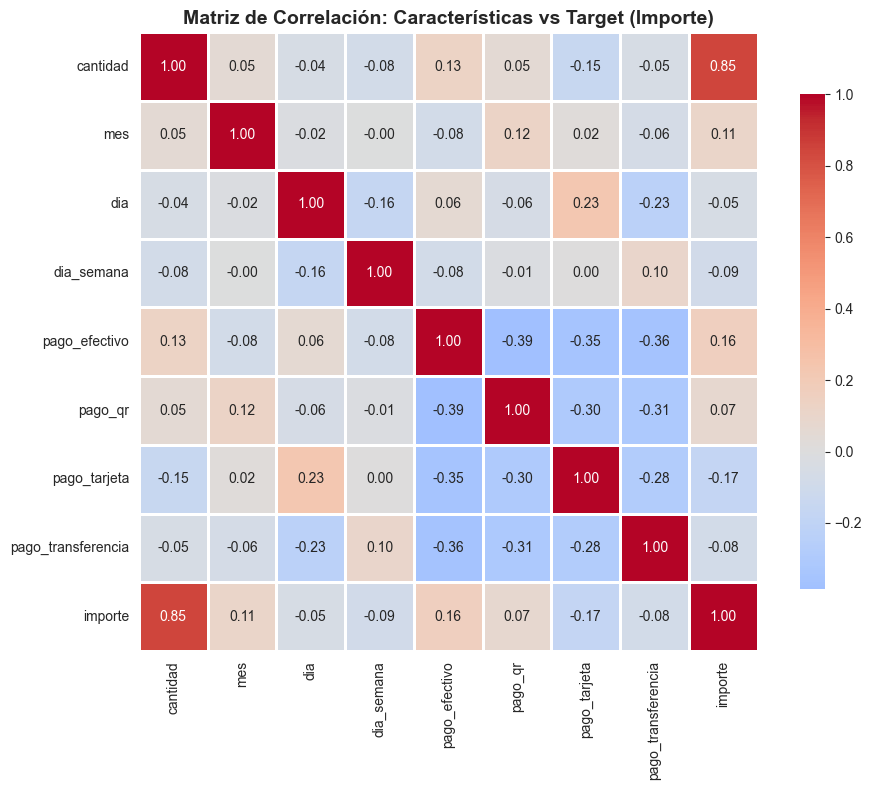

Correlación con el target (importe):
importe               1.000000
cantidad              0.845701
pago_efectivo         0.159061
mes                   0.112249
pago_qr               0.074372
dia                  -0.047088
pago_transferencia   -0.081505
dia_semana           -0.086577
pago_tarjeta         -0.173856
Name: importe, dtype: float64


In [5]:
# Matriz de correlación
correlation_data = pd.concat([X, y], axis=1)
correlation_data.columns = list(X.columns) + ['importe']

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación: Características vs Target (Importe)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlación con el target (importe):")
correlations = correlation_data.corr()['importe'].sort_values(ascending=False)
print(correlations)

## 6. Dividir Datos en Train/Test (80-20)

In [6]:
# División train/test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✓ División Train/Test:")
print(f"  - Train set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  - Test set:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n✓ Información de los conjuntos:")
print(f"  - Características: {X_train.shape[1]}")
print(f"  - Random state: 42 (reproducibilidad)")

# Estadísticas del target
print(f"\n✓ Estadísticas del target:")
print(f"  Train y: mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"  Test y:  mean={y_test.mean():.2f}, std={y_test.std():.2f}")

✓ División Train/Test:
  - Train set: 96 muestras (80.0%)
  - Test set:  24 muestras (20.0%)

✓ Información de los conjuntos:
  - Características: 8
  - Random state: 42 (reproducibilidad)

✓ Estadísticas del target:
  Train y: mean=22134.20, std=13090.17
  Test y:  mean=21938.92, std=14701.31


## 7. Entrenar Modelo de Regresión Lineal

### Algoritmo: Regresión Lineal
**Justificación:**
- **Interpretabilidad:** Fácil de entender y explicar los coeficientes
- **Relación lineal:** La cantidad de items tiene relación directa con el importe
- **Eficiencia:** Entrenamiento rápido y bajo costo computacional
- **Datos:** Dataset pequeño (119 ventas) adecuado para regresión simple

In [7]:
# Normalizar características (escalado)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("✓ Modelo de Regresión Lineal entrenado")
print(f"  - Intercept (b): {model.intercept_:.2f}")
print(f"  - Coeficientes (pesos):")

for feature, coef in zip(X.columns, model.coef_):
    print(f"    {feature:20s}: {coef:10.4f}")

✓ Modelo de Regresión Lineal entrenado
  - Intercept (b): 22134.20
  - Coeficientes (pesos):
    cantidad            : 10517.5542
    mes                 :  1092.5805
    dia                 :  -443.2007
    dia_semana          :  -327.0695
    pago_efectivo       :   717.6335
    pago_qr             :    84.4237
    pago_tarjeta        :  -568.4158
    pago_transferencia  :  -333.8673


## 8. Generar Predicciones

In [8]:
# Realizar predicciones
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("✓ Predicciones realizadas")
print(f"\nPrimeras 5 predicciones en test set:")
print(f"{'Real':>10} {'Predicción':>15} {'Error':>10}")
print("-" * 35)
for real, pred in zip(y_test.iloc[:5], y_test_pred[:5]):
    error = abs(real - pred)
    print(f"{real:10.2f} {pred:15.2f} {error:10.2f}")
print("...")

✓ Predicciones realizadas

Primeras 5 predicciones en test set:
      Real      Predicción      Error
-----------------------------------
  22751.00        27394.02    4643.02
  30101.00        23269.55    6831.45
  16360.00        11522.52    4837.48
  17220.00        14911.85    2308.15
  30232.00        17795.96   12436.04
...


## 9. Calcular Métricas de Evaluación

### Métricas para Regresión:
- **MAE (Mean Absolute Error):** Promedio del error absoluto
- **MSE (Mean Squared Error):** Promedio del error al cuadrado
- **RMSE (Root Mean Squared Error):** Raíz cuadrada de MSE
- **R² (Coeficiente de Determinación):** Proporción de varianza explicada (0-1)

In [9]:
# Calcular métricas en ENTRENAMIENTO
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Calcular métricas en PRUEBA
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

# R² ajustado
n_samples = len(y_test)
n_features = X_test.shape[1]
r2_adj_test = 1 - (1 - r2_test) * (n_samples - 1) / (n_samples - n_features - 1)

# Crear tabla de métricas
metrics_df = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²', 'R² Ajustado'],
    'Entrenamiento': [mae_train, mse_train, rmse_train, r2_train, '—'],
    'Prueba': [mae_test, mse_test, rmse_test, r2_test, r2_adj_test]
})

print("=" * 70)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=" * 70)
print(metrics_df.to_string(index=False))
print("=" * 70)

# Análisis de overfitting
print("\n✓ Análisis de Overfitting:")
mae_diff = abs(mae_test - mae_train)
print(f"  - Diferencia MAE (test - train): {mae_diff:.2f}")
if mae_test > mae_train:
    print(f"    → Posible overfitting detectado")
else:
    print(f"    → Buen balance entre train y test")

MÉTRICAS DE EVALUACIÓN DEL MODELO
    Métrica    Entrenamiento       Prueba
        MAE      5516.517026 5.158864e+03
        MSE  50097458.759145 4.411133e+07
       RMSE      7077.955832 6.641636e+03
         R²         0.704558 7.870284e-01
R² Ajustado                — 6.734435e-01

✓ Análisis de Overfitting:
  - Diferencia MAE (test - train): 357.65
    → Buen balance entre train y test


## 10. Visualización de Resultados (Gráfico 1: Real vs Predicción)

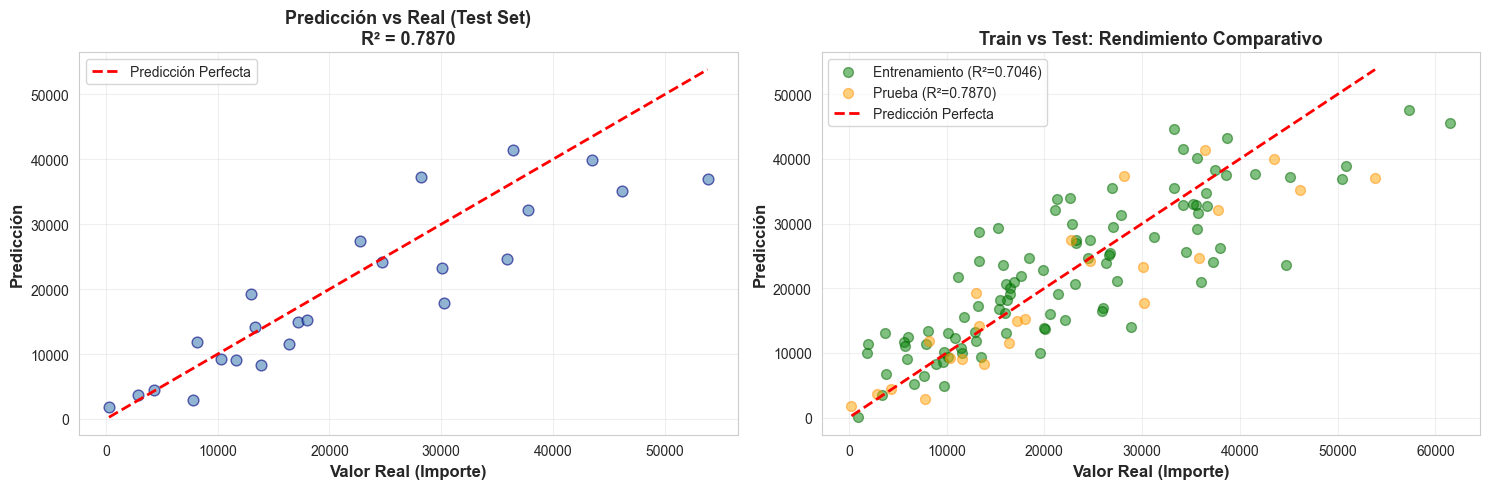

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Scatter plot - Real vs Predicción (Test)
axes[0].scatter(y_test, y_test_pred, alpha=0.6, s=60, color='steelblue', edgecolors='navy')
# Línea diagonal (predicción perfecta)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_xlabel('Valor Real (Importe)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicción', fontsize=12, fontweight='bold')
axes[0].set_title('Predicción vs Real (Test Set)\nR² = {:.4f}'.format(r2_test), 
                   fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Gráfico 2: Scatter plot - Train vs Test comparación
axes[1].scatter(y_train, y_train_pred, alpha=0.5, s=50, color='green', 
               label=f'Entrenamiento (R²={r2_train:.4f})', edgecolors='darkgreen')
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=50, color='orange', 
               label=f'Prueba (R²={r2_test:.4f})', edgecolors='darkorange')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')
axes[1].set_xlabel('Valor Real (Importe)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicción', fontsize=12, fontweight='bold')
axes[1].set_title('Train vs Test: Rendimiento Comparativo', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Visualización de Resultados (Gráfico 2: Residuos)

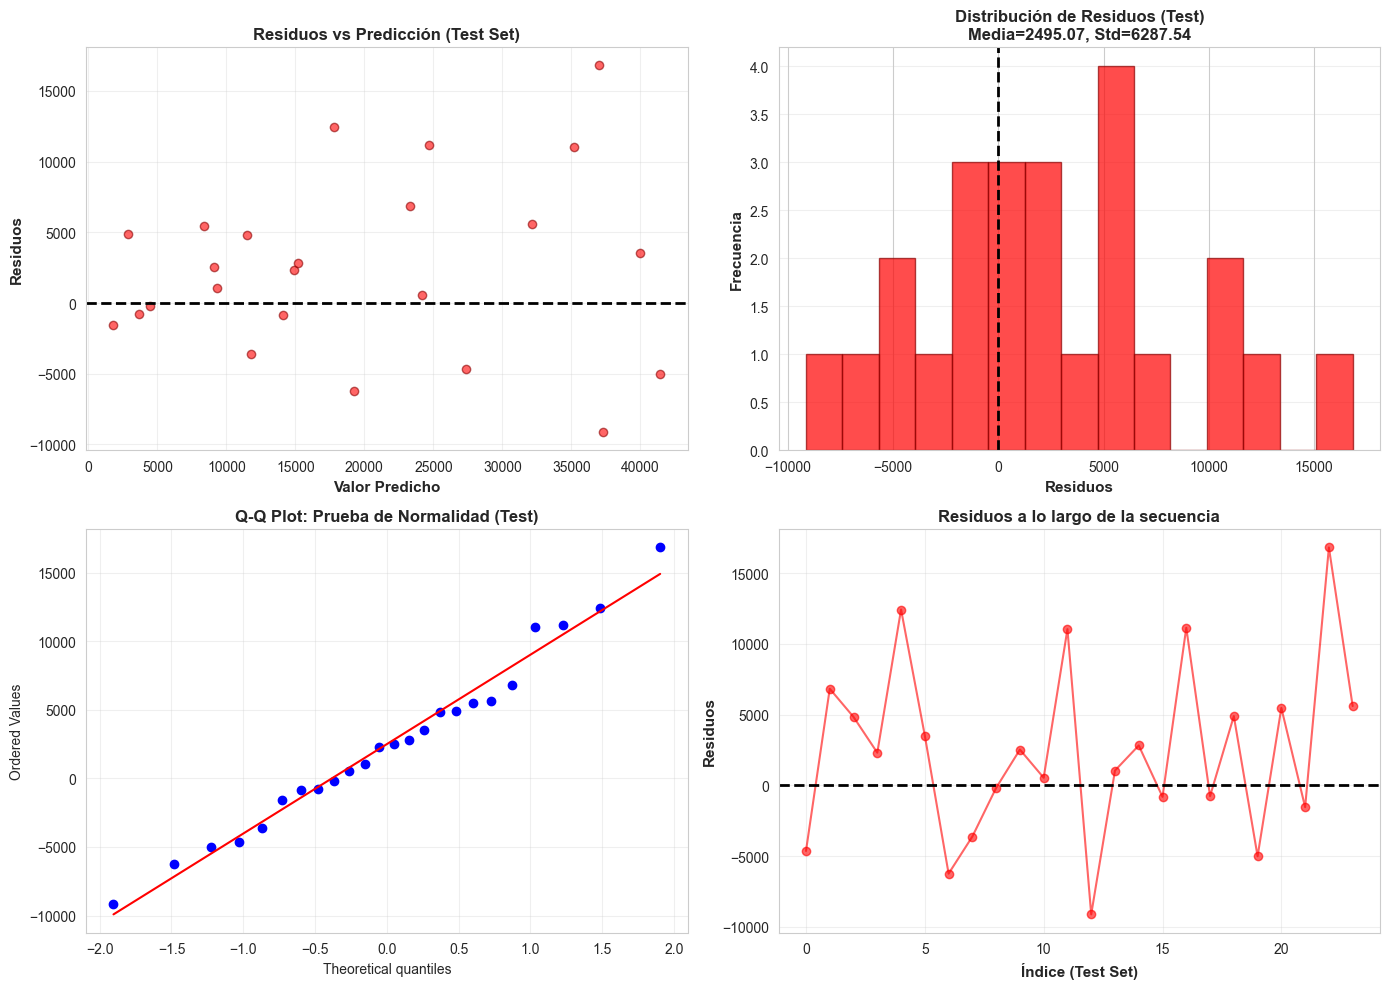

✓ Análisis de Residuos:
  - Media de residuos (test): 2495.0657 (cercano a 0 → bueno)
  - Std de residuos (test): 6287.5427
  - Min residuo: -9129.22
  - Max residuo: 16824.47


In [11]:
# Calcular residuos
residuals_test = y_test - y_test_pred
residuals_train = y_train - y_train_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Residuos vs Predicción (Test)
axes[0, 0].scatter(y_test_pred, residuals_test, alpha=0.6, color='red', edgecolors='darkred')
axes[0, 0].axhline(y=0, color='k', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Valor Predicho', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuos', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Residuos vs Predicción (Test Set)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Histograma de Residuos (Test)
axes[0, 1].hist(residuals_test, bins=15, color='red', alpha=0.7, edgecolor='darkred')
axes[0, 1].set_xlabel('Residuos', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Distribución de Residuos (Test)\nMedia={residuals_test.mean():.2f}, Std={residuals_test.std():.2f}', 
                      fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=0, color='k', linestyle='--', lw=2)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Gráfico 3: Q-Q Plot (normalidad de residuos)
from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Prueba de Normalidad (Test)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Residuos a lo largo del tiempo (índice)
axes[1, 1].plot(range(len(residuals_test)), residuals_test, 'o-', alpha=0.6, color='red')
axes[1, 1].axhline(y=0, color='k', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Índice (Test Set)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Residuos', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Residuos a lo largo de la secuencia', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Análisis de Residuos:")
print(f"  - Media de residuos (test): {residuals_test.mean():.4f} (cercano a 0 → bueno)")
print(f"  - Std de residuos (test): {residuals_test.std():.4f}")
print(f"  - Min residuo: {residuals_test.min():.2f}")
print(f"  - Max residuo: {residuals_test.max():.2f}")

## 12. Visualización de Resultados (Gráfico 3: Importancia de Características)

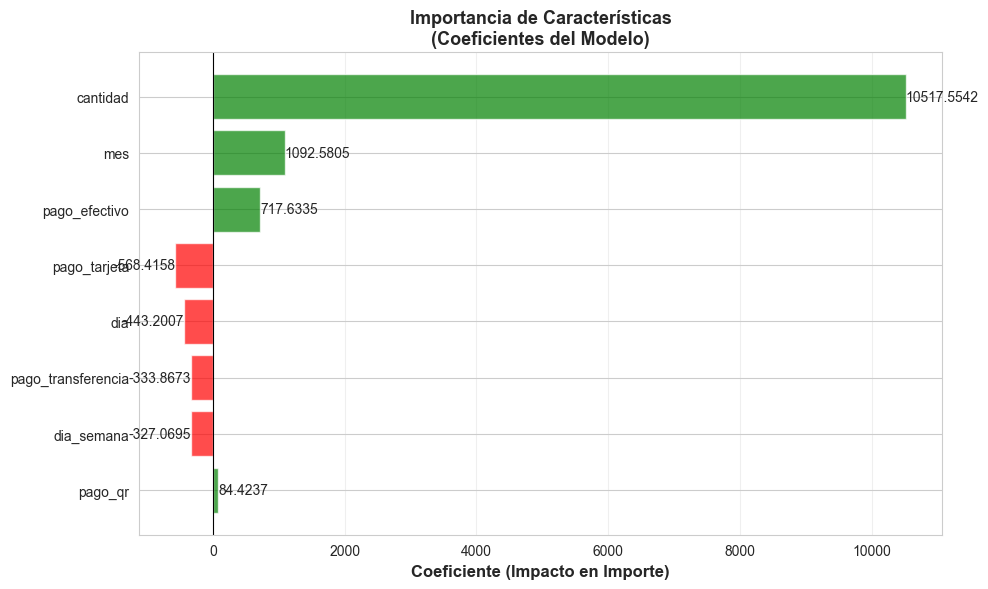

✓ Ranking de Importancia de Características:
    Característica  Coeficiente
          cantidad 10517.554170
               mes  1092.580500
     pago_efectivo   717.633532
      pago_tarjeta  -568.415791
               dia  -443.200704
pago_transferencia  -333.867259
        dia_semana  -327.069522
           pago_qr    84.423690


In [12]:
# Importancia de características (coeficientes)
feature_importance = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': model.coef_
})
feature_importance = feature_importance.sort_values('Coeficiente', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coeficiente']]
ax.barh(feature_importance['Característica'], feature_importance['Coeficiente'], color=colors, alpha=0.7)
ax.set_xlabel('Coeficiente (Impacto en Importe)', fontsize=12, fontweight='bold')
ax.set_title('Importancia de Características\n(Coeficientes del Modelo)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(feature_importance['Coeficiente']):
    ax.text(v + 0.05 if v > 0 else v - 0.05, i, f'{v:.4f}', va='center', 
            ha='left' if v > 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Ranking de Importancia de Características:")
print(feature_importance.sort_values('Coeficiente', key=abs, ascending=False).to_string(index=False))

## 13. Resumen y Conclusiones

In [13]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO DEL MODELO ML")
print("="*80)

print("\n📊 OBJETIVO:")
print("  → Predecir el importe total de una venta (REGRESIÓN)")

print("\n🔧 ALGORITMO UTILIZADO:")
print("  → Regresión Lineal (Linear Regression)")
print("  → Justificación: Relación lineal entre cantidad y importe,")
print("                   interpretabilidad, eficiencia, dataset pequeño")

print("\n📥 CARACTERÍSTICAS (X):")
for col in X.columns:
    print(f"  • {col}")

print("\n📤 TARGET (y):")
print("  • importe (valor numérico continuo)")

print("\n📈 DATOS:")
print(f"  • Total de ventas: {len(ventas_agg)}")
print(f"  • Entrenamiento: {len(X_train)} muestras (80%)")
print(f"  • Prueba: {len(X_test)} muestras (20%)")
print(f"  • Random state: 42 (reproducibilidad)")

print("\n🎯 MÉTRICAS DE EVALUACIÓN:")
print("\n  ENTRENAMIENTO:")
print(f"    • MAE:  {mae_train:>10.2f} (error promedio absoluto)")
print(f"    • RMSE: {rmse_train:>10.2f} (raíz del error cuadrático medio)")
print(f"    • R²:   {r2_train:>10.4f} (varianza explicada)")

print("\n  PRUEBA:")
print(f"    • MAE:  {mae_test:>10.2f} (error promedio absoluto)")
print(f"    • RMSE: {rmse_test:>10.2f} (raíz del error cuadrático medio)")
print(f"    • R²:   {r2_test:>10.4f} (varianza explicada)")
print(f"    • R² Ajustado: {r2_adj_test:.4f}")

print("\n💡 INTERPRETACIÓN:")
if r2_test > 0.7:
    print(f"  ✓ Excelente: El modelo explica el {r2_test*100:.1f}% de la varianza")
elif r2_test > 0.5:
    print(f"  ✓ Bueno: El modelo explica el {r2_test*100:.1f}% de la varianza")
elif r2_test > 0.3:
    print(f"  ⚠ Regular: El modelo explica el {r2_test*100:.1f}% de la varianza")
else:
    print(f"  ✗ Bajo: El modelo explica el {r2_test*100:.1f}% de la varianza")

print(f"\n  • Error promedio en test: ${mae_test:.2f}")
print(f"  • Diferencia MAE (test-train): {abs(mae_test - mae_train):.2f}")
if abs(mae_test - mae_train) < 100:
    print("    → Sin signos evidentes de overfitting")
else:
    print("    → Posible overfitting detectado")

print("\n🔑 CARACTERÍSTICAS MÁS IMPORTANTES:")
top_features = feature_importance.sort_values('Coeficiente', key=abs, ascending=False).head(3)
for idx, row in top_features.iterrows():
    print(f"  • {row['Característica']:20s}: {row['Coeficiente']:>10.4f}")

print("\n📊 VISUALIZACIONES GENERADAS:")
print("  1. Matriz de Correlación (características vs target)")
print("  2. Predicción vs Real (scatter plots)")
print("  3. Análisis de Residuos (histograma, Q-Q plot, etc.)")
print("  4. Importancia de Características (gráfico de barras)")

print("\n✅ CONCLUSIÓN:")
print(f"  El modelo de Regresión Lineal tiene un rendimiento de R²={r2_test:.4f}")
print("  en el conjunto de prueba. Es adecuado para predicciones de importe")
print("  basadas en cantidad y características temporales/de pago.")
print("\n" + "="*80)


RESUMEN EJECUTIVO DEL MODELO ML

📊 OBJETIVO:
  → Predecir el importe total de una venta (REGRESIÓN)

🔧 ALGORITMO UTILIZADO:
  → Regresión Lineal (Linear Regression)
  → Justificación: Relación lineal entre cantidad y importe,
                   interpretabilidad, eficiencia, dataset pequeño

📥 CARACTERÍSTICAS (X):
  • cantidad
  • mes
  • dia
  • dia_semana
  • pago_efectivo
  • pago_qr
  • pago_tarjeta
  • pago_transferencia

📤 TARGET (y):
  • importe (valor numérico continuo)

📈 DATOS:
  • Total de ventas: 120
  • Entrenamiento: 96 muestras (80%)
  • Prueba: 24 muestras (20%)
  • Random state: 42 (reproducibilidad)

🎯 MÉTRICAS DE EVALUACIÓN:

  ENTRENAMIENTO:
    • MAE:     5516.52 (error promedio absoluto)
    • RMSE:    7077.96 (raíz del error cuadrático medio)
    • R²:       0.7046 (varianza explicada)

  PRUEBA:
    • MAE:     5158.86 (error promedio absoluto)
    • RMSE:    6641.64 (raíz del error cuadrático medio)
    • R²:       0.7870 (varianza explicada)
    • R² Ajustado: